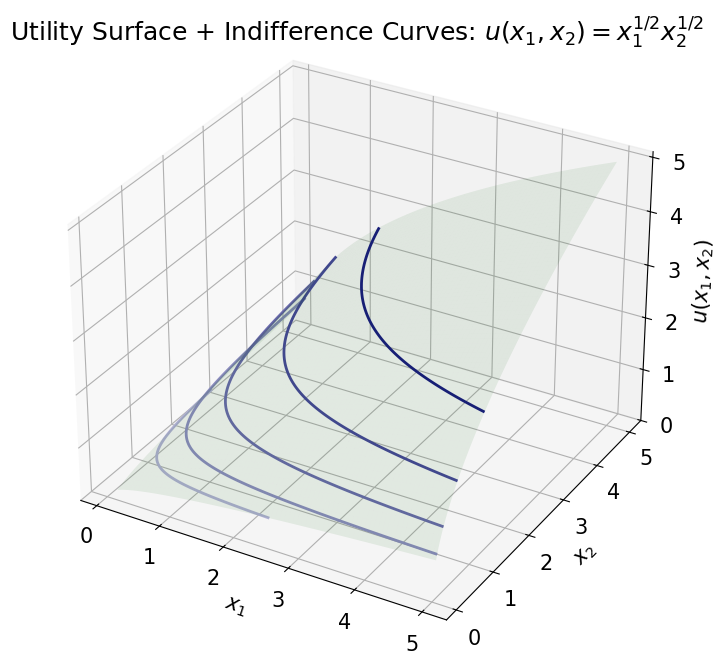

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

# Colors
ChadBlue  = (0.1, 0.1, 0.5)
ChadGreen = (0.0, 0.4, 0.0)

# Utility levels + gradient
levels = [0.5, 0.8, 1.2, 1.8, 2.6]
t_values = [0.35, 0.50, 0.65, 0.80, 1.00]
def blend_with_white(rgb, t):
    white = np.array([1.0, 1.0, 1.0])
    base = np.array(rgb)
    out = (1 - t) * white + t * base
    return tuple(out.tolist())
colors = [blend_with_white(ChadBlue, t) for t in t_values]

# Domain + utility
x1 = np.linspace(0.1, 5, 300)
x2 = np.linspace(0.1, 5, 300)
X1, X2 = np.meshgrid(x1, x2)
U = np.sqrt(X1 * X2)

# --------- 3D Surface with Contour Lines ---------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Super transparent green surface
green_with_alpha = (ChadGreen[0], ChadGreen[1], ChadGreen[2], 0.08)
ax.plot_surface(X1, X2, U, color=green_with_alpha, rstride=4, cstride=4, linewidth=0.2, antialiased=True)

# Thin indifference curves on surface
ax.contour(X1, X2, U, levels=levels, colors=colors, linewidths=2)

# Legend
handles3d = [Line2D([0], [0], color=colors[i], lw=2, label=fr"$u={levels[i]}$") for i in range(len(levels))]
#ax.legend(handles=handles3d, loc="upper right", bbox_to_anchor=(0.02, 0.98), frameon=False)

# Labels/titles
ax.set_xlabel(r"$x_1$", color="black")
ax.set_ylabel(r"$x_2$", color="black")
ax.set_zlabel(r"$u(x_1,x_2)$", color="black")
ax.set_title(r"Utility Surface + Indifference Curves: $u(x_1,x_2)=x_1^{1/2}x_2^{1/2}$", y = 1.02)

plt.rcParams.update({'font.size': 16})

plt.tight_layout()

plt.savefig("3d-plot.png", dpi=600, bbox_inches="tight")

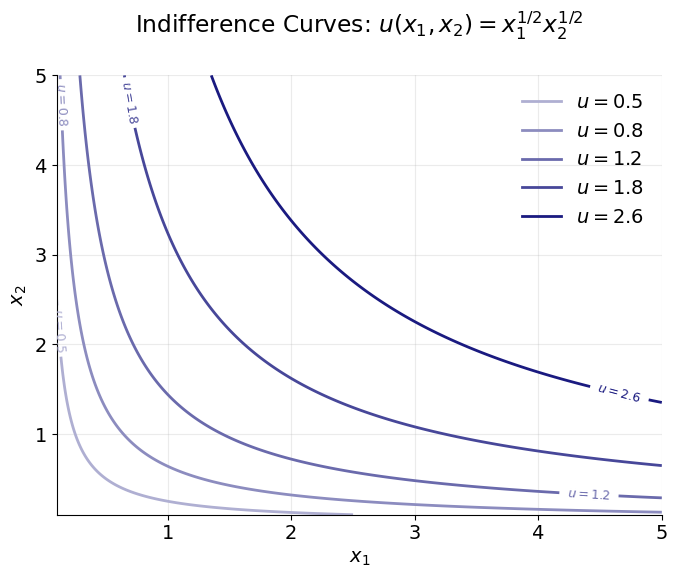

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Color utility
def blend_with_white(rgb, t):
    white = np.array([1.0, 1.0, 1.0])
    base = np.array(rgb)
    out = (1 - t) * white + t * base
    return tuple(out.tolist())

# Colors
ChadBlue = (0.1, 0.1, 0.5)
levels = [0.5, 0.8, 1.2, 1.8, 2.6]
t_values = [0.35, 0.50, 0.65, 0.80, 1.00]
colors = [blend_with_white(ChadBlue, t) for t in t_values]

# Domain + utility
x1 = np.linspace(0.1, 5, 300)
x2 = np.linspace(0.1, 5, 300)
X1, X2 = np.meshgrid(x1, x2)
U = np.sqrt(X1 * X2)

# --------- 2D Contour Plot with corrected labels and extra title spacing ---------
plt.figure(figsize=(7, 6))
CS = plt.contour(X1, X2, U, levels=levels, colors=colors, linewidths=2)

# Custom formatting: show as integers or simple decimals without ".1f"
manual_labels = {0.5:"$u=0.5$", 0.8:"$u=0.8$", 1.2:"$u=1.2$", 1.8:"$u=1.8$", 2.6:"$u=2.6$"}
plt.clabel(CS, inline=True, fontsize=9, fmt=manual_labels)

plt.xlabel(r"$x_1$", color="black")
plt.ylabel(r"$x_2$", color="black")
plt.title(r"Indifference Curves: $u(x_1,x_2)=x_1^{1/2}x_2^{1/2}$", pad=30)  # <-- extra space
plt.grid(True, alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Custom legend
handles2d = [Line2D([0],[0], color=colors[i], lw=2, label=manual_labels[levels[i]]) for i in range(len(levels))]
plt.legend(handles=handles2d, loc="upper right", frameon=False)

plt.tight_layout()

plt.rcParams.update({'font.size': 14})

plt.savefig("2d-plot.png", dpi=600, bbox_inches="tight")